## Flanking versus breaching

- Definitions (Nichols et al., 2023): Flanking = lateral scour around the berm end; breaching = perpendicular break through the berm.

- Soil-texture pattern (Results 3.1, Table 1): Flanking was more common than breaching overall. On loamy sand, 47% of berms flanked vs. 9% breached; on clay loam, 31% flanked vs. 17% breached. Coarser soils skew toward flanking; finer soils have a higher breach share.
- Vegetation effect (abstract): Where breaches occurred on coarser textured soils, up- and downslope differences in grass cover diminished.

- Interpretation (not from the paper): Sandy/loamy sand has low cohesion, so once water routes around a berm end it can incise a scour pathway quickly → more flanking. Clay loam resists end-scour, so water is more likely to pond and overtop → more breaching. [Note: Nichols et al. do not discuss this mechanism; their discussion centers on moisture-holding capacity and vegetation response.]


 Reference

- Nichols, M. H., Duke, S. E., Holifield Collins, C., & Thompson, L. (2023). Legacy earthen berms influence vegetation and hydrologic complexity in the Altar Valley, Arizona. *International Soil and Water Conservation Research*. https://doi.org/10.1016/j.iswcr.2023.01.005

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import fisher_exact, chi2_contingency
from itertools import combinations as _combinations
from matplotlib.lines import Line2D
from IPython.display import display, HTML

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module=r"seaborn(\..*)?")

pd.set_option("display.max_columns", 50)

In [2]:
import sys as _sys
_sys.path.insert(0, '../src')
from constants import (
    INTACT_COL, DEGRADED_COL, BREACH_COL, FLANK_COL,
    LF_COLORS, lf_order,
    LENGTH_COLORS, length_order,
    SLOPE_COLORS, slope_order,
    CLAY_COLORS, clay_order,
    SOILDEV_COLORS, soildev_order,
    TEXTURE_COLORS, texture_order,
    LBL_EFFECTIVE, LBL_INEFFECTIVE, eff_order, eff_colors,
    fail_order, fail_colors,
    FS, FS_SUP,
)
from plotting import (
    width, add_bar_edges,
    _sig_stars, _fisher_one_sided,
    _two_cat_metrics, _draw_two_cat_panel, _draw_multi_cat_panel,
)
from analysis import chi2_with_cramers_v, _bh_adjust
from registry import register_failure_mechanisms_figure

In [3]:
import os as _os

data = pd.read_csv('../data/merged.csv')
print(f'Loaded {len(data):,} rows')

# ── Data preparation ─────────────────────────────────────────────────────────
data['Fail_Type'] = data['Fail_Type'].fillna('Intact')
data['Condition'] = data['Fail_Type'].apply(lambda x: 'Intact' if x == 'Intact' else 'Degraded')
data = data.loc[data['Fail_Type'] != 'Breach and Flank'].copy()

_fig_dir = _os.path.join('..', 'figures', 'failure_mechanisms')
_os.makedirs(_fig_dir, exist_ok=True)

print(f"Working df: {len(data):,} rows")
print(f"\nFail_Type value counts:")
print(data['Fail_Type'].value_counts().to_string())
print(f"\nOverall proportions:")
print((data['Fail_Type'].value_counts(normalize=True) * 100).round(1).to_string())

Loaded 775 rows
Working df: 775 rows

Fail_Type value counts:
Fail_Type
Intact    458
Flank     203
Breach    114

Overall proportions:
Fail_Type
Intact    59.1
Flank     26.2
Breach    14.7


## Breaches and flanks separately

### Length × Failure type

Fisher one-sided exact tests compare Long vs Short berm outcomes.
Metrics include both unconditional (all berms) and conditional
(among failed berms only) probabilities.

In [4]:
# ── Length × Failure type: probability table + Fisher exact tests ────────────
_thr = 60

_df_len = data.query("Shape_Leng != @_thr").copy()
_df_len['len_bin'] = np.where(_df_len['Shape_Leng'] > _thr,
                              f'Long (>{_thr} m)', f'Short (<{_thr} m)')
_df_len['failed'] = _df_len['Fail_Type'].ne('Intact')

_long_lbl  = f'Long (>{_thr} m)'
_short_lbl = f'Short (<{_thr} m)'

_n_long  = len(_df_len[_df_len['len_bin'] == _long_lbl])
_n_short = len(_df_len[_df_len['len_bin'] == _short_lbl])

# Unconditional metrics
_rows = {}
for _metric, _pos_fn in [
    ('Intact',       lambda d: d['Fail_Type'] == 'Intact'),
    ('Any failure',  lambda d: d['failed']),
    ('Breach',       lambda d: d['Fail_Type'] == 'Breach'),
    ('Flank',        lambda d: d['Fail_Type'] == 'Flank'),
    (LBL_EFFECTIVE,  lambda d: d['Effective'] == LBL_EFFECTIVE),
]:
    _mask = _pos_fn(_df_len)
    _c_l = _mask[_df_len['len_bin'] == _long_lbl].sum()
    _c_s = _mask[_df_len['len_bin'] == _short_lbl].sum()
    _p_val, _direction = _fisher_one_sided(_c_l, _n_long, _c_s, _n_short)
    _p_l, _p_s = _c_l / _n_long, _c_s / _n_short
    _rows[_metric] = {
        _long_lbl: _p_l, _short_lbl: _p_s,
        '\u0394': round(_p_l - _p_s, 3),
        'direction': f"Long {'>' if _p_l >= _p_s else '<'} Short",
        'p-value (1-sided)': _p_val,
        'sig': _sig_stars(_p_val),
    }

# Conditional metrics (among failed only)
_df_f = _df_len[_df_len['failed']]
_n_lf = (_df_f['len_bin'] == _long_lbl).sum()
_n_sf = (_df_f['len_bin'] == _short_lbl).sum()
for _metric, _ft in [('Breach | failed', 'Breach'), ('Flank | failed', 'Flank')]:
    _c_l = ((_df_f['Fail_Type'] == _ft) & (_df_f['len_bin'] == _long_lbl)).sum()
    _c_s = ((_df_f['Fail_Type'] == _ft) & (_df_f['len_bin'] == _short_lbl)).sum()
    _p_val, _direction = _fisher_one_sided(_c_l, _n_lf, _c_s, _n_sf)
    _p_l, _p_s = _c_l / _n_lf, _c_s / _n_sf
    _rows[_metric] = {
        _long_lbl: _p_l, _short_lbl: _p_s,
        '\u0394': round(_p_l - _p_s, 3),
        'direction': f"Long {'>' if _p_l >= _p_s else '<'} Short",
        'p-value (1-sided)': _p_val,
        'sig': _sig_stars(_p_val),
    }

len_metrics = pd.DataFrame(_rows).T
len_metrics[[_long_lbl, _short_lbl]] = len_metrics[[_long_lbl, _short_lbl]].astype(float)

display(len_metrics.assign(
    **{_long_lbl:  (len_metrics[_long_lbl]  * 100).round(1),
       _short_lbl: (len_metrics[_short_lbl] * 100).round(1),
       '\u0394':  len_metrics['\u0394'].astype(float).round(3),
       'p-value (1-sided)': len_metrics['p-value (1-sided)'].apply(lambda x: f'{x:.3g}')}
)[[_long_lbl, _short_lbl, '\u0394', 'direction', 'p-value (1-sided)', 'sig']])

,Long (>60 m),Short (<60 m),Δ,direction,p-value (1-sided),sig
Intact,47.1,70.4,-0.234,Long < Short,2.63e-11,***
Any failure,52.9,29.6,0.234,Long > Short,2.63e-11,***
Breach,21.8,8.0,0.138,Long > Short,3.78e-08,***
Flank,31.1,21.6,0.096,Long > Short,0.00161,**
Vegetation response,48.7,46.4,0.023,Long > Short,0.284,ns
Breach | failed,41.2,27.1,0.141,Long > Short,0.00765,**
Flank | failed,58.8,72.9,-0.141,Long < Short,0.00765,**


Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 2)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt


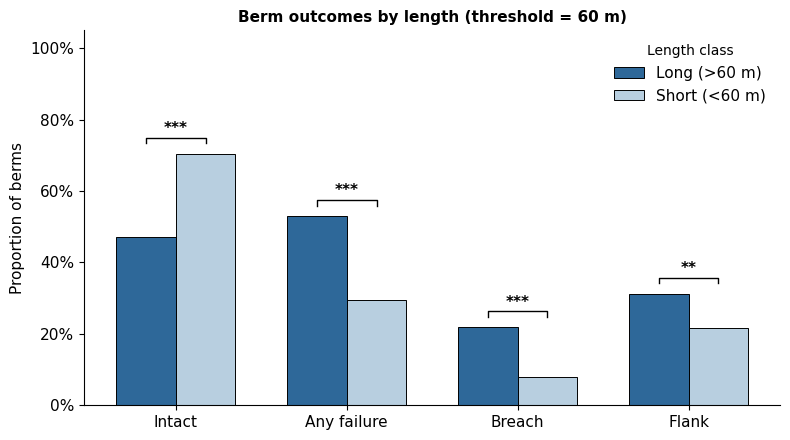

Saved: fig2_length_fail_type_brackets.png


In [5]:
# ── Length × Failure type figure: grouped bars with significance brackets ────
_FS = FS

_plot_metrics = ['Intact', 'Any failure', 'Breach', 'Flank']

fig, ax = plt.subplots(figsize=(8, 4.5))

_bar_colors = {_long_lbl:  LENGTH_COLORS['Long (> 60 m)'],
               _short_lbl: LENGTH_COLORS['Short (≤ 60 m)']}
_x = np.arange(len(_plot_metrics))
_w = 0.35

for _lbl, _offset in [(_long_lbl, -_w / 2), (_short_lbl, _w / 2)]:
    _vals = [len_metrics.loc[m, _lbl] for m in _plot_metrics]
    ax.bar(_x + _offset, _vals, _w, label=_lbl,
           color=_bar_colors[_lbl], edgecolor='black', linewidth=0.7)

# Significance brackets
for _i, _metric in enumerate(_plot_metrics):
    _sig = len_metrics.loc[_metric, 'sig']
    _p_l = len_metrics.loc[_metric, _long_lbl]
    _p_s = len_metrics.loc[_metric, _short_lbl]
    _top = max(_p_l, _p_s) + 0.03
    _bh  = 0.015
    ax.plot([_x[_i] - _w/2, _x[_i] - _w/2, _x[_i] + _w/2, _x[_i] + _w/2],
            [_top, _top + _bh, _top + _bh, _top], lw=1, color='black')
    _col = 'black' if _sig != 'ns' else '#888888'
    ax.text(_x[_i], _top + _bh + 0.005, _sig, ha='center', va='bottom',
            fontsize=_FS, color=_col,
            fontweight='bold' if _sig != 'ns' else 'normal')

ax.set_xticks(_x)
ax.set_xticklabels(_plot_metrics, fontsize=_FS)
ax.set_ylabel('Proportion of berms', fontsize=_FS)
ax.set_title(f'Berm outcomes by length (threshold = {_thr} m)', fontsize=_FS, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.tick_params(labelsize=_FS)
ax.legend(title='Length class', frameon=False, fontsize=_FS)
sns.despine(ax=ax)
plt.tight_layout()

_fname = 'fig2_length_fail_type_brackets.png'
fig.savefig(_os.path.join(_fig_dir, _fname), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig2', _fname,
    f'Grouped comparison of berm outcome proportions between Long and Short '
    f'berm classes (threshold {_thr} m), with per-metric one-sided '
    f'Fisher exact significance brackets.',
    f'Outcome proportions differ by length class. Longer berms show higher '
    f'failure rates and a greater breach share among failures.',
)
plt.show()
print(f'Saved: {_fname}')

### Slope × Failure type

Fisher one-sided exact tests compare Steep vs Shallow berm outcomes.
Metrics include both unconditional (all berms) and conditional
(among failed berms only) probabilities.

In [6]:
# ── Slope × Failure type: probability table + Fisher exact tests ─────────────
_shallow_lbl = 'Shallow (≤ 2%)'
_steep_lbl   = 'Steep (> 2%)'

_df_slope = data.dropna(subset=['Slope_Class']).copy()
_df_slope['failed'] = _df_slope['Fail_Type'].ne('Intact')

_n_steep   = (_df_slope['Slope_Class'] == _steep_lbl).sum()
_n_shallow = (_df_slope['Slope_Class'] == _shallow_lbl).sum()

# Unconditional metrics
_rows_sl = {}
for _metric, _pos_fn in [
    ('Intact',       lambda d: d['Fail_Type'] == 'Intact'),
    ('Any failure',  lambda d: d['failed']),
    ('Breach',       lambda d: d['Fail_Type'] == 'Breach'),
    ('Flank',        lambda d: d['Fail_Type'] == 'Flank'),
    (LBL_EFFECTIVE,  lambda d: d['Effective'] == LBL_EFFECTIVE),
]:
    _mask = _pos_fn(_df_slope)
    _c_st = _mask[_df_slope['Slope_Class'] == _steep_lbl].sum()
    _c_sh = _mask[_df_slope['Slope_Class'] == _shallow_lbl].sum()
    _p_val, _direction = _fisher_one_sided(_c_st, _n_steep, _c_sh, _n_shallow)
    _p_st, _p_sh = _c_st / _n_steep, _c_sh / _n_shallow
    _rows_sl[_metric] = {
        _steep_lbl: _p_st, _shallow_lbl: _p_sh,
        '\u0394': round(_p_st - _p_sh, 3),
        'direction': f"Steep {'>' if _p_st >= _p_sh else '<'} Shallow",
        'p-value (1-sided)': _p_val,
        'sig': _sig_stars(_p_val),
    }

# Conditional metrics (among failed only)
_df_sf = _df_slope[_df_slope['failed']]
_n_stf = (_df_sf['Slope_Class'] == _steep_lbl).sum()
_n_shf = (_df_sf['Slope_Class'] == _shallow_lbl).sum()
for _metric, _ft in [('Breach | failed', 'Breach'), ('Flank | failed', 'Flank')]:
    _c_st = ((_df_sf['Fail_Type'] == _ft) & (_df_sf['Slope_Class'] == _steep_lbl)).sum()
    _c_sh = ((_df_sf['Fail_Type'] == _ft) & (_df_sf['Slope_Class'] == _shallow_lbl)).sum()
    _p_val, _direction = _fisher_one_sided(_c_st, _n_stf, _c_sh, _n_shf)
    _p_st, _p_sh = _c_st / _n_stf, _c_sh / _n_shf
    _rows_sl[_metric] = {
        _steep_lbl: _p_st, _shallow_lbl: _p_sh,
        '\u0394': round(_p_st - _p_sh, 3),
        'direction': f"Steep {'>' if _p_st >= _p_sh else '<'} Shallow",
        'p-value (1-sided)': _p_val,
        'sig': _sig_stars(_p_val),
    }

slope_metrics = pd.DataFrame(_rows_sl).T
slope_metrics[[_steep_lbl, _shallow_lbl]] = slope_metrics[[_steep_lbl, _shallow_lbl]].astype(float)

display(slope_metrics.assign(
    **{_steep_lbl:   (slope_metrics[_steep_lbl]   * 100).round(1),
       _shallow_lbl: (slope_metrics[_shallow_lbl] * 100).round(1),
       '\u0394':  slope_metrics['\u0394'].astype(float).round(3),
       'p-value (1-sided)': slope_metrics['p-value (1-sided)'].apply(lambda x: f'{x:.3g}')}
)[[_steep_lbl, _shallow_lbl, '\u0394', 'direction', 'p-value (1-sided)', 'sig']])

,Steep (> 2%),Shallow (≤ 2%),Δ,direction,p-value (1-sided),sig
Intact,55.0,63.3,-0.083,Steep < Shallow,0.0114,*
Any failure,45.0,36.7,0.083,Steep > Shallow,0.0114,*
Breach,13.0,16.4,-0.034,Steep < Shallow,0.111,ns
Flank,32.0,20.3,0.117,Steep > Shallow,0.000147,***
Vegetation response,57.0,37.8,0.193,Steep > Shallow,5.3e-08,***
Breach | failed,29.0,44.7,-0.157,Steep < Shallow,0.00275,**
Flank | failed,71.0,55.3,0.157,Steep > Shallow,0.00275,**


Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 2)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt


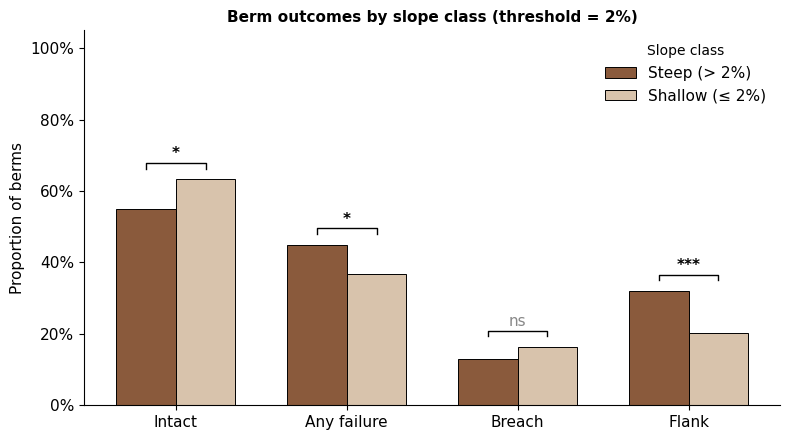

Saved: fig2b_slope_fail_type_brackets.png


In [7]:
# ── Slope × Failure type figure: grouped bars with significance brackets ─────
_FS = FS

_plot_metrics_sl = ['Intact', 'Any failure', 'Breach', 'Flank']

fig, ax = plt.subplots(figsize=(8, 4.5))

_bar_colors_sl = {_steep_lbl:   SLOPE_COLORS['Steep (> 2%)'],
                  _shallow_lbl: SLOPE_COLORS['Shallow (≤ 2%)']}
_x = np.arange(len(_plot_metrics_sl))
_w = 0.35

for _lbl, _offset in [(_steep_lbl, -_w / 2), (_shallow_lbl, _w / 2)]:
    _vals = [slope_metrics.loc[m, _lbl] for m in _plot_metrics_sl]
    ax.bar(_x + _offset, _vals, _w, label=_lbl,
           color=_bar_colors_sl[_lbl], edgecolor='black', linewidth=0.7)

# Significance brackets
for _i, _metric in enumerate(_plot_metrics_sl):
    _sig = slope_metrics.loc[_metric, 'sig']
    _p_st = slope_metrics.loc[_metric, _steep_lbl]
    _p_sh = slope_metrics.loc[_metric, _shallow_lbl]
    _top = max(_p_st, _p_sh) + 0.03
    _bh  = 0.015
    ax.plot([_x[_i] - _w/2, _x[_i] - _w/2, _x[_i] + _w/2, _x[_i] + _w/2],
            [_top, _top + _bh, _top + _bh, _top], lw=1, color='black')
    _col = 'black' if _sig != 'ns' else '#888888'
    ax.text(_x[_i], _top + _bh + 0.005, _sig, ha='center', va='bottom',
            fontsize=_FS, color=_col,
            fontweight='bold' if _sig != 'ns' else 'normal')

ax.set_xticks(_x)
ax.set_xticklabels(_plot_metrics_sl, fontsize=_FS)
ax.set_ylabel('Proportion of berms', fontsize=_FS)
ax.set_title('Berm outcomes by slope class (threshold = 2%)', fontsize=_FS, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.tick_params(labelsize=_FS)
ax.legend(title='Slope class', frameon=False, fontsize=_FS)
sns.despine(ax=ax)
plt.tight_layout()

_fname = 'fig2b_slope_fail_type_brackets.png'
fig.savefig(_os.path.join(_fig_dir, _fname), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig2b', _fname,
    f'Grouped comparison of berm outcome proportions between Steep and Shallow '
    f'slope classes (threshold 2%), with per-metric one-sided '
    f'Fisher exact significance brackets.',
    f'Outcome proportions compared by slope class. Steeper slopes may show '
    f'different failure rates and failure type distributions.',
)
plt.show()
print(f'Saved: {_fname}')

### Soil development (B horizon) × Failure type

Fisher one-sided exact tests compare B horizon vs No B horizon berm outcomes.
Metrics include both unconditional (all berms) and conditional
(among failed berms only) probabilities.

In [8]:
# ── Soil development × Failure type: probability table + Fisher exact tests ──
_bhor_lbl   = 'B horizon'
_nobhor_lbl = 'No B horizon'

_df_sd = data.dropna(subset=['Soil_Development']).copy()
_df_sd['failed'] = _df_sd['Fail_Type'].ne('Intact')

_n_bh  = (_df_sd['Soil_Development'] == _bhor_lbl).sum()
_n_nbh = (_df_sd['Soil_Development'] == _nobhor_lbl).sum()

# Unconditional metrics
_rows_sd = {}
for _metric, _pos_fn in [
    ('Intact',       lambda d: d['Fail_Type'] == 'Intact'),
    ('Any failure',  lambda d: d['failed']),
    ('Breach',       lambda d: d['Fail_Type'] == 'Breach'),
    ('Flank',        lambda d: d['Fail_Type'] == 'Flank'),
    (LBL_EFFECTIVE,  lambda d: d['Effective'] == LBL_EFFECTIVE),
]:
    _mask = _pos_fn(_df_sd)
    _c_bh  = _mask[_df_sd['Soil_Development'] == _bhor_lbl].sum()
    _c_nbh = _mask[_df_sd['Soil_Development'] == _nobhor_lbl].sum()
    _p_val, _direction = _fisher_one_sided(_c_bh, _n_bh, _c_nbh, _n_nbh)
    _p_bh, _p_nbh = _c_bh / _n_bh, _c_nbh / _n_nbh
    _rows_sd[_metric] = {
        _bhor_lbl: _p_bh, _nobhor_lbl: _p_nbh,
        '\u0394': round(_p_bh - _p_nbh, 3),
        'direction': f"B hor {'>' if _p_bh >= _p_nbh else '<'} No B hor",
        'p-value (1-sided)': _p_val,
        'sig': _sig_stars(_p_val),
    }

# Conditional metrics (among failed only)
_df_sdf = _df_sd[_df_sd['failed']]
_n_bhf  = (_df_sdf['Soil_Development'] == _bhor_lbl).sum()
_n_nbhf = (_df_sdf['Soil_Development'] == _nobhor_lbl).sum()
for _metric, _ft in [('Breach | failed', 'Breach'), ('Flank | failed', 'Flank')]:
    _c_bh  = ((_df_sdf['Fail_Type'] == _ft) & (_df_sdf['Soil_Development'] == _bhor_lbl)).sum()
    _c_nbh = ((_df_sdf['Fail_Type'] == _ft) & (_df_sdf['Soil_Development'] == _nobhor_lbl)).sum()
    _p_val, _direction = _fisher_one_sided(_c_bh, _n_bhf, _c_nbh, _n_nbhf)
    _p_bh, _p_nbh = _c_bh / _n_bhf, _c_nbh / _n_nbhf
    _rows_sd[_metric] = {
        _bhor_lbl: _p_bh, _nobhor_lbl: _p_nbh,
        '\u0394': round(_p_bh - _p_nbh, 3),
        'direction': f"B hor {'>' if _p_bh >= _p_nbh else '<'} No B hor",
        'p-value (1-sided)': _p_val,
        'sig': _sig_stars(_p_val),
    }

sd_metrics = pd.DataFrame(_rows_sd).T
sd_metrics[[_bhor_lbl, _nobhor_lbl]] = sd_metrics[[_bhor_lbl, _nobhor_lbl]].astype(float)

display(sd_metrics.assign(
    **{_bhor_lbl:   (sd_metrics[_bhor_lbl]   * 100).round(1),
       _nobhor_lbl: (sd_metrics[_nobhor_lbl] * 100).round(1),
       '\u0394':  sd_metrics['\u0394'].astype(float).round(3),
       'p-value (1-sided)': sd_metrics['p-value (1-sided)'].apply(lambda x: f'{x:.3g}')}
)[[_bhor_lbl, _nobhor_lbl, '\u0394', 'direction', 'p-value (1-sided)', 'sig']])

,B horizon,No B horizon,Δ,direction,p-value (1-sided),sig
Intact,54.7,61.7,-0.071,B hor < No B hor,0.0318,*
Any failure,45.3,38.3,0.071,B hor > No B hor,0.0318,*
Breach,11.8,16.5,-0.047,B hor < No B hor,0.0452,*
Flank,33.6,21.8,0.118,B hor > No B hor,0.000245,***
Vegetation response,55.4,42.8,0.126,B hor > No B hor,0.000459,***
Breach | failed,26.0,43.0,-0.171,B hor < No B hor,0.00125,**
Flank | failed,74.0,57.0,0.171,B hor > No B hor,0.00125,**


Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 2)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt


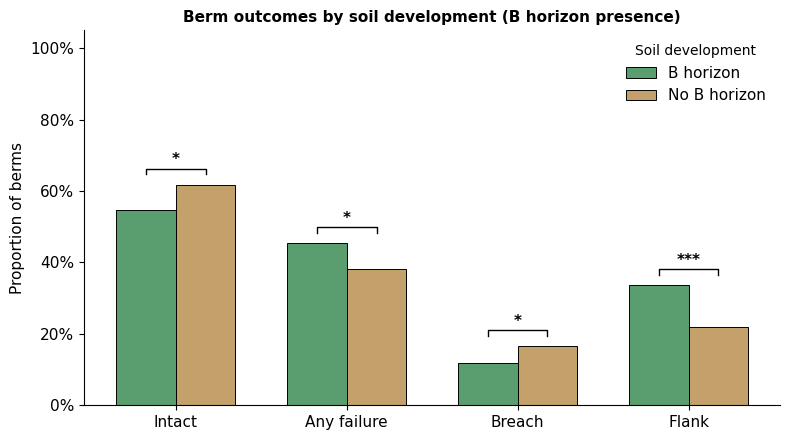

Saved: fig2c_soildev_fail_type_brackets.png


In [9]:
# ── Soil development × Failure type figure: grouped bars with brackets ────────
_FS = FS

_plot_metrics_sd = ['Intact', 'Any failure', 'Breach', 'Flank']

fig, ax = plt.subplots(figsize=(8, 4.5))

_bar_colors_sd = {_bhor_lbl:   SOILDEV_COLORS['B horizon'],
                  _nobhor_lbl: SOILDEV_COLORS['No B horizon']}
_x = np.arange(len(_plot_metrics_sd))
_w = 0.35

for _lbl, _offset in [(_bhor_lbl, -_w / 2), (_nobhor_lbl, _w / 2)]:
    _vals = [sd_metrics.loc[m, _lbl] for m in _plot_metrics_sd]
    ax.bar(_x + _offset, _vals, _w, label=_lbl,
           color=_bar_colors_sd[_lbl], edgecolor='black', linewidth=0.7)

# Significance brackets
for _i, _metric in enumerate(_plot_metrics_sd):
    _sig = sd_metrics.loc[_metric, 'sig']
    _p_bh  = sd_metrics.loc[_metric, _bhor_lbl]
    _p_nbh = sd_metrics.loc[_metric, _nobhor_lbl]
    _top = max(_p_bh, _p_nbh) + 0.03
    _bh  = 0.015
    ax.plot([_x[_i] - _w/2, _x[_i] - _w/2, _x[_i] + _w/2, _x[_i] + _w/2],
            [_top, _top + _bh, _top + _bh, _top], lw=1, color='black')
    _col = 'black' if _sig != 'ns' else '#888888'
    ax.text(_x[_i], _top + _bh + 0.005, _sig, ha='center', va='bottom',
            fontsize=_FS, color=_col,
            fontweight='bold' if _sig != 'ns' else 'normal')

ax.set_xticks(_x)
ax.set_xticklabels(_plot_metrics_sd, fontsize=_FS)
ax.set_ylabel('Proportion of berms', fontsize=_FS)
ax.set_title('Berm outcomes by soil development (B horizon presence)', fontsize=_FS, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.tick_params(labelsize=_FS)
ax.legend(title='Soil development', frameon=False, fontsize=_FS)
sns.despine(ax=ax)
plt.tight_layout()

_fname = 'fig2c_soildev_fail_type_brackets.png'
fig.savefig(_os.path.join(_fig_dir, _fname), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig2c', _fname,
    f'Grouped comparison of berm outcome proportions between B horizon and '
    f'No B horizon soil classes, with per-metric one-sided '
    f'Fisher exact significance brackets.',
    f'Outcome proportions compared by soil development. B horizon presence '
    f'may influence failure rates and failure type distributions.',
)
plt.show()
print(f'Saved: {_fname}')

### Soil texture × Failure type (top 3 textures, fine → coarse)

Grouped bar chart with pairwise Fisher exact significance brackets.
Only the three most common textures are included: Clay loam, Silt loam,
Sandy loam (ordered fine → coarse per `texture_order`).

In [10]:
# ── Soil texture × Failure type: probability table + pairwise Fisher tests ───

# Top 3 textures by count, ordered fine → coarse via texture_order
_tex_counts = data['Texture'].value_counts()
_top3 = [t for t in texture_order if t in _tex_counts.nlargest(3).index]
_tex_colors_top3 = {t: TEXTURE_COLORS[t] for t in _top3}

_df_tex = data[data['Texture'].isin(_top3)].copy()
_df_tex['failed'] = _df_tex['Fail_Type'].ne('Intact')

_n_tex = {t: (_df_tex['Texture'] == t).sum() for t in _top3}

# Overall chi-square for Texture × Fail_Type
_ct_tex = pd.crosstab(_df_tex['Texture'], _df_tex['Fail_Type'])
_ct_tex = _ct_tex.reindex(columns=fail_order, fill_value=0).reindex(_top3)
_chi2_tex, _p_tex, _dof_tex, _V_tex, _ = chi2_with_cramers_v(_ct_tex)
_p_str_tex = f'p = {_p_tex:.3g}' if _p_tex >= 0.001 else 'p < 0.001'

# Unconditional metrics
_rows_tx = {}
for _metric, _pos_fn in [
    ('Intact',       lambda d: d['Fail_Type'] == 'Intact'),
    ('Any failure',  lambda d: d['failed']),
    ('Breach',       lambda d: d['Fail_Type'] == 'Breach'),
    ('Flank',        lambda d: d['Fail_Type'] == 'Flank'),
    (LBL_EFFECTIVE,  lambda d: d['Effective'] == LBL_EFFECTIVE),
]:
    _mask = _pos_fn(_df_tex)
    _row = {}
    for _t in _top3:
        _c = _mask[_df_tex['Texture'] == _t].sum()
        _row[_t] = _c / _n_tex[_t]
    # Pairwise Fisher tests
    for _ci, _cj in _combinations(range(len(_top3)), 2):
        _ta, _tb = _top3[_ci], _top3[_cj]
        _ca = _mask[_df_tex['Texture'] == _ta].sum()
        _cb = _mask[_df_tex['Texture'] == _tb].sum()
        _p_val, _ = _fisher_one_sided(_ca, _n_tex[_ta], _cb, _n_tex[_tb])
        _row[f'{_ta[:2]}v{_tb[:2]} p'] = _p_val
        _row[f'{_ta[:2]}v{_tb[:2]} sig'] = _sig_stars(_p_val)
    _rows_tx[_metric] = _row

# Conditional metrics (among failed only)
_df_txf = _df_tex[_df_tex['failed']]
_n_tex_f = {t: (_df_txf['Texture'] == t).sum() for t in _top3}
for _metric, _ft in [('Breach | failed', 'Breach'), ('Flank | failed', 'Flank')]:
    _row = {}
    for _t in _top3:
        _c = ((_df_txf['Fail_Type'] == _ft) & (_df_txf['Texture'] == _t)).sum()
        _row[_t] = _c / _n_tex_f[_t] if _n_tex_f[_t] > 0 else float('nan')
    for _ci, _cj in _combinations(range(len(_top3)), 2):
        _ta, _tb = _top3[_ci], _top3[_cj]
        _ca = ((_df_txf['Fail_Type'] == _ft) & (_df_txf['Texture'] == _ta)).sum()
        _cb = ((_df_txf['Fail_Type'] == _ft) & (_df_txf['Texture'] == _tb)).sum()
        _p_val, _ = _fisher_one_sided(_ca, _n_tex_f[_ta], _cb, _n_tex_f[_tb])
        _row[f'{_ta[:2]}v{_tb[:2]} p'] = _p_val
        _row[f'{_ta[:2]}v{_tb[:2]} sig'] = _sig_stars(_p_val)
    _rows_tx[_metric] = _row

tex_metrics = pd.DataFrame(_rows_tx).T

print(f"Texture × Fail_Type  χ² = {_chi2_tex:.2f}, {_p_str_tex}, Cramér's V = {_V_tex:.2f}")
print(f"Textures (fine → coarse): {_top3}")
print(f"n per texture: { {t: _n_tex[t] for t in _top3} }")
print()

# Display proportions + pairwise significance
_disp = tex_metrics.copy()
for _t in _top3:
    _disp[_t] = (_disp[_t].astype(float) * 100).round(1)
_sig_cols = [c for c in _disp.columns if c.endswith(' sig')]
_p_cols   = [c for c in _disp.columns if c.endswith(' p')]
display(_disp[_top3 + _sig_cols])

Texture × Fail_Type  χ² = 30.82, p < 0.001, Cramér's V = 0.16
Textures (fine → coarse): ['Clay loam', 'Silt loam', 'Sandy loam']
n per texture: {'Clay loam': 283, 'Silt loam': 137, 'Sandy loam': 210}



,Clay loam,Silt loam,Sandy loam,ClvSi sig,ClvSa sig,SivSa sig
Intact,61.8,64.2,46.2,ns,***,***
Any failure,38.2,35.8,53.8,ns,***,***
Breach,18.7,13.9,13.3,ns,ns,ns
Flank,19.4,21.9,40.5,ns,***,***
Vegetation response,39.2,54.0,60.0,**,***,ns
Breach | failed,49.1,38.8,24.8,ns,***,ns
Flank | failed,50.9,61.2,75.2,ns,***,ns


Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 2)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt


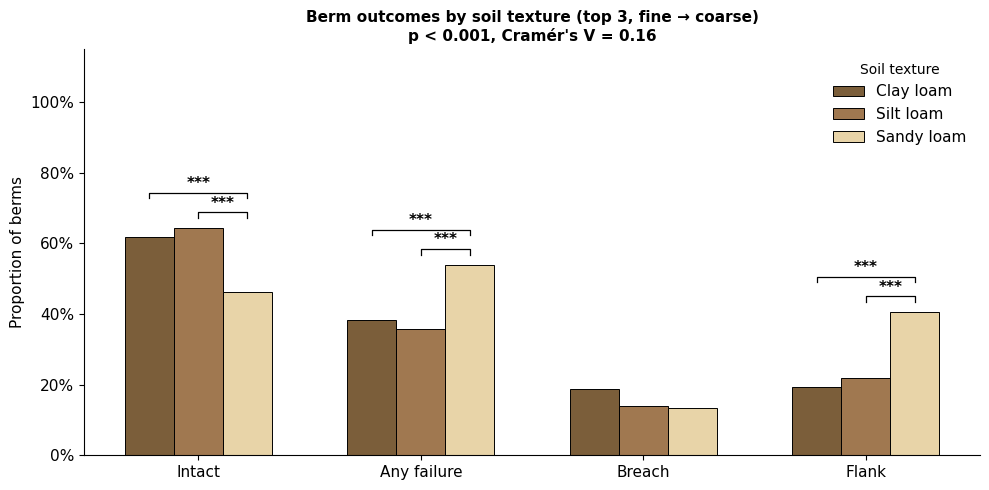

Saved: fig2d_texture_fail_type.png


In [11]:
# ── Soil texture × Failure type figure: grouped bars with brackets ────────────
_FS = FS

_plot_metrics_tx = ['Intact', 'Any failure', 'Breach', 'Flank']

fig, ax = plt.subplots(figsize=(10, 5))

_n_tex_bars = len(_top3)
_w = 0.22
_offsets = np.linspace(-(_n_tex_bars - 1) * _w / 2,
                       (_n_tex_bars - 1) * _w / 2, _n_tex_bars)
_x = np.arange(len(_plot_metrics_tx))

for _ti, _tex in enumerate(_top3):
    _vals = [tex_metrics.loc[m, _tex] for m in _plot_metrics_tx]
    ax.bar(_x + _offsets[_ti], _vals, _w, label=_tex,
           color=_tex_colors_top3[_tex], edgecolor='black', linewidth=0.7)

# Pairwise significance brackets per metric
_bh = 0.015
for _mi, _metric in enumerate(_plot_metrics_tx):
    _pairs = list(_combinations(range(_n_tex_bars), 2))
    _pairs.sort(key=lambda p: abs(_offsets[p[1]] - _offsets[p[0]]))
    _current_top = max(tex_metrics.loc[_metric, _tex] for _tex in _top3) + 0.03
    for _ci, _cj in _pairs:
        _ta, _tb = _top3[_ci], _top3[_cj]
        _sig_key = f'{_ta[:2]}v{_tb[:2]} sig'
        _stars = tex_metrics.loc[_metric, _sig_key]
        if _stars == 'ns':
            continue
        _x_a = _mi + _offsets[_ci]
        _x_b = _mi + _offsets[_cj]
        _y_a = tex_metrics.loc[_metric, _ta]
        _y_b = tex_metrics.loc[_metric, _tb]
        _yb = max(max(_y_a, _y_b) + 0.02, _current_top)
        ax.plot([_x_a, _x_a, _x_b, _x_b],
                [_yb, _yb + _bh, _yb + _bh, _yb], lw=0.9, color='black')
        ax.text((_x_a + _x_b) / 2, _yb + _bh + 0.005, _stars,
                ha='center', va='bottom', fontsize=_FS,
                fontweight='bold', color='black')
        _current_top = _yb + _bh + 0.04

ax.set_xticks(_x)
ax.set_xticklabels(_plot_metrics_tx, fontsize=_FS)
ax.set_ylabel('Proportion of berms', fontsize=_FS)
ax.set_title(f"Berm outcomes by soil texture (top 3, fine \u2192 coarse)\n"
             f"{_p_str_tex}, Cram\u00e9r's V = {_V_tex:.2f}", fontsize=_FS, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.tick_params(labelsize=_FS)
ax.legend(title='Soil texture', frameon=False, fontsize=_FS)
sns.despine(ax=ax)
plt.tight_layout()

_fname = 'fig2d_texture_fail_type.png'
fig.savefig(_os.path.join(_fig_dir, _fname), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig2d', _fname,
    f'Grouped comparison of berm outcome proportions across top 3 soil textures '
    f'({", ".join(_top3)}, fine \u2192 coarse) with pairwise one-sided Fisher exact '
    f'significance brackets. \u03c7\u00b2 = {_chi2_tex:.2f}, {_p_str_tex}, '
    f"Cram\u00e9r's V = {_V_tex:.2f}.",
    f'Outcome proportions compared by soil texture. Finer textures show higher '
    f'breach share; coarser textures skew toward flanking.',
)
plt.show()
print(f'Saved: {_fname}')

### Landform × Failure type

Pairwise one-sided Fisher exact tests compare landform classes.
Metrics include both unconditional (all berms) and conditional
(among failed berms only) probabilities.

In [12]:
# ── Landform × Failure type: probability table + pairwise Fisher tests ────────

_df_lf = data.dropna(subset=['Landform']).copy()
_df_lf['failed'] = _df_lf['Fail_Type'].ne('Intact')

_n_lf = {lf: (_df_lf['Landform'] == lf).sum() for lf in lf_order}

# Overall chi-square for Landform × Fail_Type
_ct_lf = pd.crosstab(_df_lf['Landform'], _df_lf['Fail_Type'])
_ct_lf = _ct_lf.reindex(columns=fail_order, fill_value=0).reindex(lf_order)
_chi2_lf, _p_lf, _dof_lf, _V_lf, _ = chi2_with_cramers_v(_ct_lf)
_p_str_lf = f'p = {_p_lf:.3g}' if _p_lf >= 0.001 else 'p < 0.001'

# Unconditional metrics
_rows_lf = {}
for _metric, _pos_fn in [
    ('Intact',       lambda d: d['Fail_Type'] == 'Intact'),
    ('Any failure',  lambda d: d['failed']),
    ('Breach',       lambda d: d['Fail_Type'] == 'Breach'),
    ('Flank',        lambda d: d['Fail_Type'] == 'Flank'),
    (LBL_EFFECTIVE,  lambda d: d['Effective'] == LBL_EFFECTIVE),
]:
    _mask = _pos_fn(_df_lf)
    _row = {}
    for _lf in lf_order:
        _c = _mask[_df_lf['Landform'] == _lf].sum()
        _row[_lf] = _c / _n_lf[_lf]
    # Pairwise Fisher tests
    for _ci, _cj in _combinations(range(len(lf_order)), 2):
        _la, _lb = lf_order[_ci], lf_order[_cj]
        _ca = _mask[_df_lf['Landform'] == _la].sum()
        _cb = _mask[_df_lf['Landform'] == _lb].sum()
        _p_val, _ = _fisher_one_sided(_ca, _n_lf[_la], _cb, _n_lf[_lb])
        _row[f'{_la[:2]}v{_lb[:2]} p'] = _p_val
        _row[f'{_la[:2]}v{_lb[:2]} sig'] = _sig_stars(_p_val)
    _rows_lf[_metric] = _row

# Conditional metrics (among failed only)
_df_lff = _df_lf[_df_lf['failed']]
_n_lf_f = {lf: (_df_lff['Landform'] == lf).sum() for lf in lf_order}
for _metric, _ft in [('Breach | failed', 'Breach'), ('Flank | failed', 'Flank')]:
    _row = {}
    for _lf in lf_order:
        _c = ((_df_lff['Fail_Type'] == _ft) & (_df_lff['Landform'] == _lf)).sum()
        _row[_lf] = _c / _n_lf_f[_lf] if _n_lf_f[_lf] > 0 else float('nan')
    for _ci, _cj in _combinations(range(len(lf_order)), 2):
        _la, _lb = lf_order[_ci], lf_order[_cj]
        _ca = ((_df_lff['Fail_Type'] == _ft) & (_df_lff['Landform'] == _la)).sum()
        _cb = ((_df_lff['Fail_Type'] == _ft) & (_df_lff['Landform'] == _lb)).sum()
        _p_val, _ = _fisher_one_sided(_ca, _n_lf_f[_la], _cb, _n_lf_f[_lb])
        _row[f'{_la[:2]}v{_lb[:2]} p'] = _p_val
        _row[f'{_la[:2]}v{_lb[:2]} sig'] = _sig_stars(_p_val)
    _rows_lf[_metric] = _row

lf_metrics = pd.DataFrame(_rows_lf).T

print(f"Landform × Fail_Type  χ² = {_chi2_lf:.2f}, {_p_str_lf}, Cramér's V = {_V_lf:.2f}")
print(f"Landforms: {lf_order}")
print(f"n per landform: { {lf: _n_lf[lf] for lf in lf_order} }")
print()

# Display proportions + pairwise significance
_disp_lf = lf_metrics.copy()
for _lf in lf_order:
    _disp_lf[_lf] = (_disp_lf[_lf].astype(float) * 100).round(1)
_sig_cols_lf = [c for c in _disp_lf.columns if c.endswith(' sig')]
display(_disp_lf[lf_order + _sig_cols_lf])

Landform × Fail_Type  χ² = 14.41, p = 0.00609, Cramér's V = 0.10
Landforms: ['Fan terraces', 'Stream terraces', 'Flood plains']
n per landform: {'Fan terraces': 276, 'Stream terraces': 140, 'Flood plains': 359}



,Fan terraces,Stream terraces,Flood plains,FavSt sig,FavFl sig,StvFl sig
Intact,55.4,64.3,59.9,ns,ns,ns
Any failure,44.6,35.7,40.1,ns,ns,ns
Breach,11.2,13.6,17.8,ns,*,ns
Flank,33.3,22.1,22.3,*,**,ns
Vegetation response,54.3,53.6,39.8,ns,***,**
Breach | failed,25.2,38.0,44.4,ns,***,ns
Flank | failed,74.8,62.0,55.6,ns,***,ns


Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 3)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt


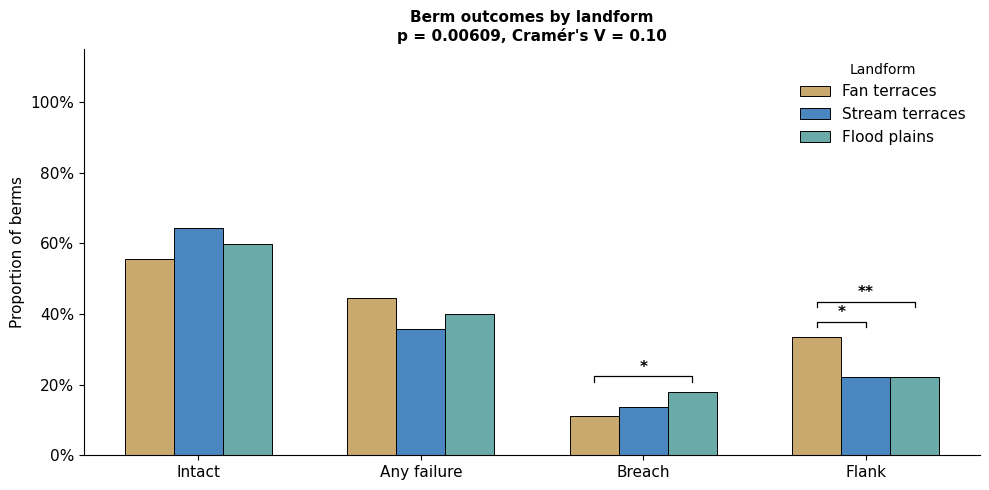

Saved: fig3_landform_fail_type.png


In [13]:
# ── Landform × Failure type figure: grouped bars with brackets ────────────────
_FS = FS

_plot_metrics_lf = ['Intact', 'Any failure', 'Breach', 'Flank']

fig, ax = plt.subplots(figsize=(10, 5))

_n_lf_bars = len(lf_order)
_w = 0.22
_offsets = np.linspace(-(_n_lf_bars - 1) * _w / 2,
                       (_n_lf_bars - 1) * _w / 2, _n_lf_bars)
_x = np.arange(len(_plot_metrics_lf))

for _li, _lf in enumerate(lf_order):
    _vals = [lf_metrics.loc[m, _lf] for m in _plot_metrics_lf]
    ax.bar(_x + _offsets[_li], _vals, _w, label=_lf,
           color=LF_COLORS.get(_lf, '#aaaaaa'), edgecolor='black', linewidth=0.7)

# Pairwise significance brackets per metric
_bh = 0.015
for _mi, _metric in enumerate(_plot_metrics_lf):
    _pairs = list(_combinations(range(_n_lf_bars), 2))
    _pairs.sort(key=lambda p: abs(_offsets[p[1]] - _offsets[p[0]]))
    _current_top = max(lf_metrics.loc[_metric, _lf] for _lf in lf_order) + 0.03
    for _ci, _cj in _pairs:
        _la, _lb = lf_order[_ci], lf_order[_cj]
        _sig_key = f'{_la[:2]}v{_lb[:2]} sig'
        _stars = lf_metrics.loc[_metric, _sig_key]
        if _stars == 'ns':
            continue
        _x_a = _mi + _offsets[_ci]
        _x_b = _mi + _offsets[_cj]
        _y_a = lf_metrics.loc[_metric, _la]
        _y_b = lf_metrics.loc[_metric, _lb]
        _yb = max(max(_y_a, _y_b) + 0.02, _current_top)
        ax.plot([_x_a, _x_a, _x_b, _x_b],
                [_yb, _yb + _bh, _yb + _bh, _yb], lw=0.9, color='black')
        ax.text((_x_a + _x_b) / 2, _yb + _bh + 0.005, _stars,
                ha='center', va='bottom', fontsize=_FS,
                fontweight='bold', color='black')
        _current_top = _yb + _bh + 0.04

ax.set_xticks(_x)
ax.set_xticklabels(_plot_metrics_lf, fontsize=_FS)
ax.set_ylabel('Proportion of berms', fontsize=_FS)
ax.set_title(f"Berm outcomes by landform\n{_p_str_lf}, Cram\u00e9r's V = {_V_lf:.2f}",
             fontsize=_FS, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.tick_params(labelsize=_FS)
ax.legend(title='Landform', frameon=False, fontsize=_FS)
sns.despine(ax=ax)
plt.tight_layout()

_fname = 'fig3_landform_fail_type.png'
fig.savefig(_os.path.join(_fig_dir, _fname), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig3', _fname,
    f'Grouped comparison of berm outcome proportions across landforms '
    f'({", ".join(lf_order)}) with pairwise one-sided Fisher exact '
    f'significance brackets. \u03c7\u00b2 = {_chi2_lf:.2f}, {_p_str_lf}, '
    f"Cram\u00e9r's V = {_V_lf:.2f}.",
    f'Outcome proportions compared by landform. Fan terraces show highest '
    f'flanking rate; flood plains highest breach rate.',
)
plt.show()
print(f'Saved: {_fname}')

In [14]:
# ── length_outcome_probs() utility ────────────────────────────────────────────
def length_outcome_probs(df, threshold=60, length_col='Shape_Leng',
                         fail_col='Fail_Type', intact_val='Intact'):
    """Print conditional outcome probabilities for berms above/below a
    length threshold.  Returns a DataFrame."""
    d = df.query(f"{length_col} != @threshold").copy()
    _long  = d[d[length_col] > threshold]
    _short = d[d[length_col] < threshold]

    def _p(subset, condition):
        n = len(subset)
        k = condition(subset).sum()
        return k / n if n > 0 else float('nan'), k, n

    _outcomes = {
        'Any failure': lambda s: s[fail_col] != intact_val,
        'Breach':      lambda s: s[fail_col] == 'Breach',
        'Flank':       lambda s: s[fail_col] == 'Flank',
        'Intact':      lambda s: s[fail_col] == intact_val,
    }
    _cond = {
        'Breach | failed': lambda s: s[fail_col] == 'Breach',
        'Flank  | failed': lambda s: s[fail_col] == 'Flank',
    }

    _header = f"{'Metric':<22}  {'Long (>' + str(threshold) + 'm)':>14}  {'Short (<' + str(threshold) + 'm)':>14}  {'Δ':>8}"
    print(_header)
    print('-' * len(_header))

    _rows = []
    for _label, _fn in _outcomes.items():
        _p_l, _k_l, _n_l = _p(_long,  _fn)
        _p_s, _k_s, _n_s = _p(_short, _fn)
        _delta = _p_l - _p_s
        print(f'  {_label:<20}  {_p_l:>6.1%} ({_k_l}/{_n_l})  '
              f'{_p_s:>6.1%} ({_k_s}/{_n_s})  {_delta:>+7.1f} pp')
        _rows.append({
            'Metric': _label, 'Among': 'All',
            f'Long (>{threshold} m) k/n': f'{_k_l}/{_n_l}',
            f'Long (>{threshold} m) %':   f'{_p_l:.1%}',
            f'Short (<{threshold} m) k/n': f'{_k_s}/{_n_s}',
            f'Short (<{threshold} m) %':   f'{_p_s:.1%}',
            '\u0394': f'{_delta:+.3f}',
        })

    print()
    _failed_long  = _long[_long[fail_col]  != intact_val]
    _failed_short = _short[_short[fail_col] != intact_val]
    print(f"  {'[Among failed only]':<20}")
    for _label, _fn in _cond.items():
        _p_l, _k_l, _n_l = _p(_failed_long,  _fn)
        _p_s, _k_s, _n_s = _p(_failed_short, _fn)
        _delta = _p_l - _p_s
        print(f'  {_label:<20}  {_p_l:>6.1%} ({_k_l}/{_n_l})  '
              f'{_p_s:>6.1%} ({_k_s}/{_n_s})  {_delta:>+7.1f} pp')
        _rows.append({
            'Metric': _label, 'Among': 'Failed only',
            f'Long (>{threshold} m) k/n': f'{_k_l}/{_n_l}',
            f'Long (>{threshold} m) %':   f'{_p_l:.1%}',
            f'Short (<{threshold} m) k/n': f'{_k_s}/{_n_s}',
            f'Short (<{threshold} m) %':   f'{_p_s:.1%}',
            '\u0394': f'{_delta:+.3f}',
        })

    return pd.DataFrame(_rows)

_length_df = length_outcome_probs(data, threshold=60)

Metric                     Long (>60m)    Short (<60m)         Δ
----------------------------------------------------------------
  Any failure            52.9% (199/376)   29.6% (118/399)     +0.2 pp
  Breach                 21.8% (82/376)    8.0% (32/399)     +0.1 pp
  Flank                  31.1% (117/376)   21.6% (86/399)     +0.1 pp
  Intact                 47.1% (177/376)   70.4% (281/399)     -0.2 pp

  [Among failed only] 
  Breach | failed        41.2% (82/199)   27.1% (32/118)     +0.1 pp
  Flank  | failed        58.8% (117/199)   72.9% (86/118)     -0.1 pp


## SI Table Exports

In [15]:
# ── Export tables as CSV ──────────────────────────────────────────────────────
_si_dir = _os.path.join(_fig_dir, 'si_tables')
_os.makedirs(_si_dir, exist_ok=True)

# SI Table 1: Length × outcome Fisher exact results
len_metrics.to_csv(_os.path.join(_si_dir, 'SI_table1_length_outcomes.csv'))
print('SI Table 1 — Length × outcome Fisher exact results:')
display(len_metrics)

# SI Table 2: Conditional probability table
_length_df.to_csv(_os.path.join(_si_dir, 'SI_table2_conditional_probs.csv'), index=False)
print('\nSI Table 2 — Conditional probabilities saved.')

print(f'\nAll SI tables saved to: {_si_dir}/')

SI Table 1 — Length × outcome Fisher exact results:


,Long (>60 m),Short (<60 m),Δ,direction,p-value (1-sided),sig
Intact,0.470745,0.704261,-0.234,Long < Short,0.0,***
Any failure,0.529255,0.295739,0.234,Long > Short,0.0,***
Breach,0.218085,0.080201,0.138,Long > Short,0.0,***
Flank,0.311170,0.215539,0.096,Long > Short,0.001606,**
Vegetation response,0.486702,0.463659,0.023,Long > Short,0.284326,ns
Breach | failed,0.412060,0.271186,0.141,Long > Short,0.007655,**
Flank | failed,0.587940,0.728814,-0.141,Long < Short,0.007655,**



SI Table 2 — Conditional probabilities saved.

All SI tables saved to: ../figures/failure_mechanisms/si_tables/
